In [2]:
# Cell 1 — Install and import
!pip install pyreadr

import pyreadr
import pandas as pd

# Load the files
unemployed = pyreadr.read_r(r'C:\Users\anura\Downloads\unemployed_total.rda')
regions = pyreadr.read_r(r'C:\Users\anura\Downloads\region_codes.rda')
occupations = pyreadr.read_r(r'C:\Users\anura\Downloads\occupational_group_codes.rda')

# Check what's inside
print("Unemployed keys:", list(unemployed.keys()))
print("Regions keys:", list(regions.keys()))
print("Occupations keys:", list(occupations.keys()))

Unemployed keys: ['unemployed_total']
Regions keys: ['region_codes']
Occupations keys: ['occupational_group_codes']


In [3]:
# Cell 2 — Load & Explore
df_unemployed = unemployed['unemployed_total']
df_regions = regions['region_codes']
df_occupations = occupations['occupational_group_codes']

print("Unemployed shape:", df_unemployed.shape)
print("\nUnemployed columns:", df_unemployed.columns.tolist())
print("\nUnemployed sample:")
print(df_unemployed.head())

print("\n" + "="*50)
print("Regions shape:", df_regions.shape)
print("Regions sample:")
print(df_regions.head())

print("\n" + "="*50)
print("Occupations shape:", df_occupations.shape)
print("Occupations sample:")
print(df_occupations.head())

Unemployed shape: (580000, 5)

Unemployed columns: ['region', 'occupational_group', 'year', 'total', 'women']

Unemployed sample:
  region occupational_group  year      total     women
0  01001                111  2012  15.250000  1.083333
1  01001                111  2013  14.666667  2.000000
2  01001                111  2014  12.500000  1.583333
3  01001                111  2015  10.833333  1.500000
4  01001                111  2016  12.916667  1.333333

Regions shape: (401, 2)
Regions sample:
    code                    name
0  01001        Flensburg, Stadt
1  01002  Kiel, Landeshauptstadt
2  01003      Lübeck, Hansestadt
3  01004       Neumünster, Stadt
4  01051            Dithmarschen

Occupations shape: (145, 2)
Occupations sample:
  code              name
0  111    Landwirtschaft
1  112    Tierwirtschaft
2  113  Pferdewirtschaft
3  114   Fischwirtschaft
4  115        Tierpflege


In [4]:
# Cell 3 — Merge & Clean
# Convert codes to same type for merging
df_unemployed['region'] = df_unemployed['region'].astype(str)
df_regions['code'] = df_regions['code'].astype(str)
df_occupations['code'] = df_occupations['code'].astype(str)
df_unemployed['occupational_group'] = df_unemployed['occupational_group'].astype(str)

# Merge region names
df = df_unemployed.merge(df_regions, left_on='region', right_on='code', how='left')
df = df.rename(columns={'name': 'region_name'})

# Merge occupation names
df = df.merge(df_occupations, left_on='occupational_group', right_on='code', how='left')
df = df.rename(columns={'name': 'occupation_name'})

# Drop redundant code columns
df = df.drop(['code_x', 'code_y'], axis=1)

# Add German state from region code (first 2 digits)
state_map = {
    '01': 'Schleswig-Holstein', '02': 'Hamburg', '03': 'Niedersachsen',
    '04': 'Bremen', '05': 'Nordrhein-Westfalen', '06': 'Hessen',
    '07': 'Rheinland-Pfalz', '08': 'Baden-Württemberg', '09': 'Bayern',
    '10': 'Saarland', '11': 'Berlin', '12': 'Brandenburg',
    '13': 'Mecklenburg-Vorpommern', '14': 'Sachsen', '15': 'Sachsen-Anhalt',
    '16': 'Thüringen'
}
df['state'] = df['region'].str[:2].map(state_map)

print("Merged dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nSample:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Merged dataset shape: (580000, 8)

Columns: ['region', 'occupational_group', 'year', 'total', 'women', 'region_name', 'occupation_name', 'state']

Sample:
  region occupational_group  year      total     women       region_name  \
0  01001                111  2012  15.250000  1.083333  Flensburg, Stadt   
1  01001                111  2013  14.666667  2.000000  Flensburg, Stadt   
2  01001                111  2014  12.500000  1.583333  Flensburg, Stadt   
3  01001                111  2015  10.833333  1.500000  Flensburg, Stadt   
4  01001                111  2016  12.916667  1.333333  Flensburg, Stadt   

  occupation_name               state  
0  Landwirtschaft  Schleswig-Holstein  
1  Landwirtschaft  Schleswig-Holstein  
2  Landwirtschaft  Schleswig-Holstein  
3  Landwirtschaft  Schleswig-Holstein  
4  Landwirtschaft  Schleswig-Holstein  

Missing values:
region                    0
occupational_group        0
year                      0
total                 11520
women              

In [5]:
# Cell 4 — Clean & Aggregate
# Fill missing occupation names
df['occupation_name'] = df['occupation_name'].fillna('Other/Unclassified')

# Drop rows where total unemployment is missing
df_clean = df.dropna(subset=['total'])
print(f"Rows after cleaning: {len(df_clean):,}")

# Create state-level aggregation by year
state_yearly = df_clean.groupby(['state', 'year']).agg(
    total_unemployed = ('total', 'sum'),
    women_unemployed = ('women', 'sum')
).reset_index()

state_yearly['women_pct'] = (
    state_yearly['women_unemployed'] / 
    state_yearly['total_unemployed'] * 100
).round(1)

# National level by year
national_yearly = df_clean.groupby('year').agg(
    total_unemployed = ('total', 'sum')
).reset_index()

# Top occupations nationally
top_occupations = df_clean.groupby('occupation_name')['total'].sum()\
    .sort_values(ascending=False).head(15)

print("\nNational unemployment trend:")
print(national_yearly)
print("\nTop 5 occupations by unemployment:")
print(top_occupations.head())

Rows after cleaning: 568,480

National unemployment trend:
   year  total_unemployed
0  2012      2.676673e+06
1  2013      2.909520e+06
2  2014      2.875345e+06
3  2015      2.754006e+06
4  2016      2.666431e+06
5  2017      2.520187e+06
6  2018      2.297767e+06
7  2019      2.257047e+06
8  2020      2.673991e+06
9  2021      2.588726e+06

Top 5 occupations by unemployment:
occupation_name
Lagerwirt.,Post,Zustellung,Güterumschlag    2.336074e+06
Verkauf (ohne Produktspezialisierung)       2.308878e+06
Reinigung                                   2.250117e+06
Büro und Sekretariat                        1.885924e+06
Other/Unclassified                          1.552125e+06
Name: total, dtype: float64


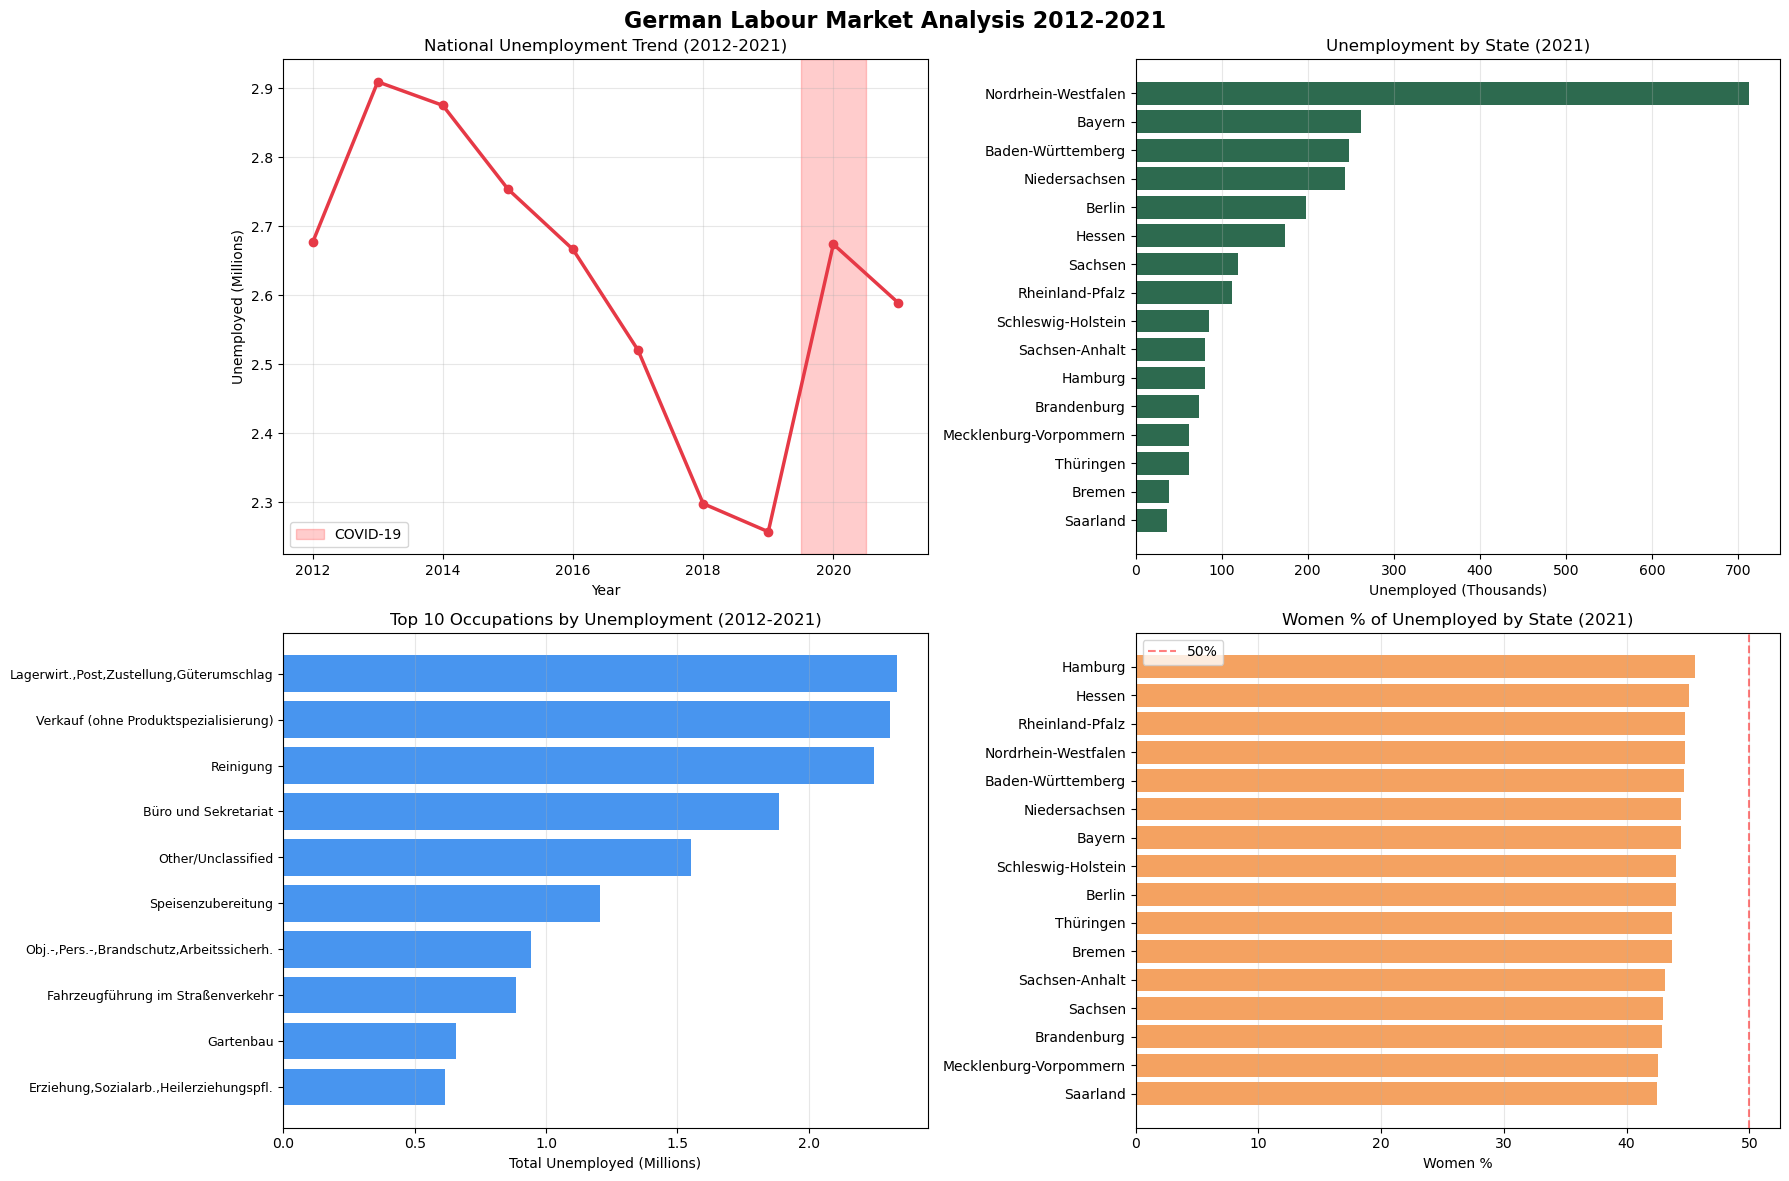

In [6]:
# Cell 5 — EDA Visualisations
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('German Labour Market Analysis 2012-2021', 
             fontsize=16, fontweight='bold')

# 1. National Unemployment Trend
axes[0,0].plot(national_yearly['year'], 
               national_yearly['total_unemployed']/1e6,
               marker='o', color='#e63946', linewidth=2.5)
axes[0,0].axvspan(2019.5, 2020.5, alpha=0.2, color='red', label='COVID-19')
axes[0,0].set_title('National Unemployment Trend (2012-2021)')
axes[0,0].set_ylabel('Unemployed (Millions)')
axes[0,0].set_xlabel('Year')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Unemployment by State (2021)
state_2021 = state_yearly[state_yearly['year']==2021]\
    .sort_values('total_unemployed', ascending=True)
axes[0,1].barh(state_2021['state'], 
               state_2021['total_unemployed']/1e3,
               color='#2d6a4f')
axes[0,1].set_title('Unemployment by State (2021)')
axes[0,1].set_xlabel('Unemployed (Thousands)')
axes[0,1].grid(True, alpha=0.3, axis='x')

# 3. Top 10 Occupations by Unemployment
top10 = top_occupations.head(10)
axes[1,0].barh(range(len(top10)), top10.values/1e6, color='#4895ef')
axes[1,0].set_yticks(range(len(top10)))
axes[1,0].set_yticklabels(top10.index, fontsize=9)
axes[1,0].set_title('Top 10 Occupations by Unemployment (2012-2021)')
axes[1,0].set_xlabel('Total Unemployed (Millions)')
axes[1,0].invert_yaxis()
axes[1,0].grid(True, alpha=0.3, axis='x')

# 4. Women % of Unemployed by State (2021)
women_2021 = state_yearly[state_yearly['year']==2021]\
    .sort_values('women_pct', ascending=True)
axes[1,1].barh(women_2021['state'], 
               women_2021['women_pct'],
               color='#f4a261')
axes[1,1].set_title('Women % of Unemployed by State (2021)')
axes[1,1].set_xlabel('Women %')
axes[1,1].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

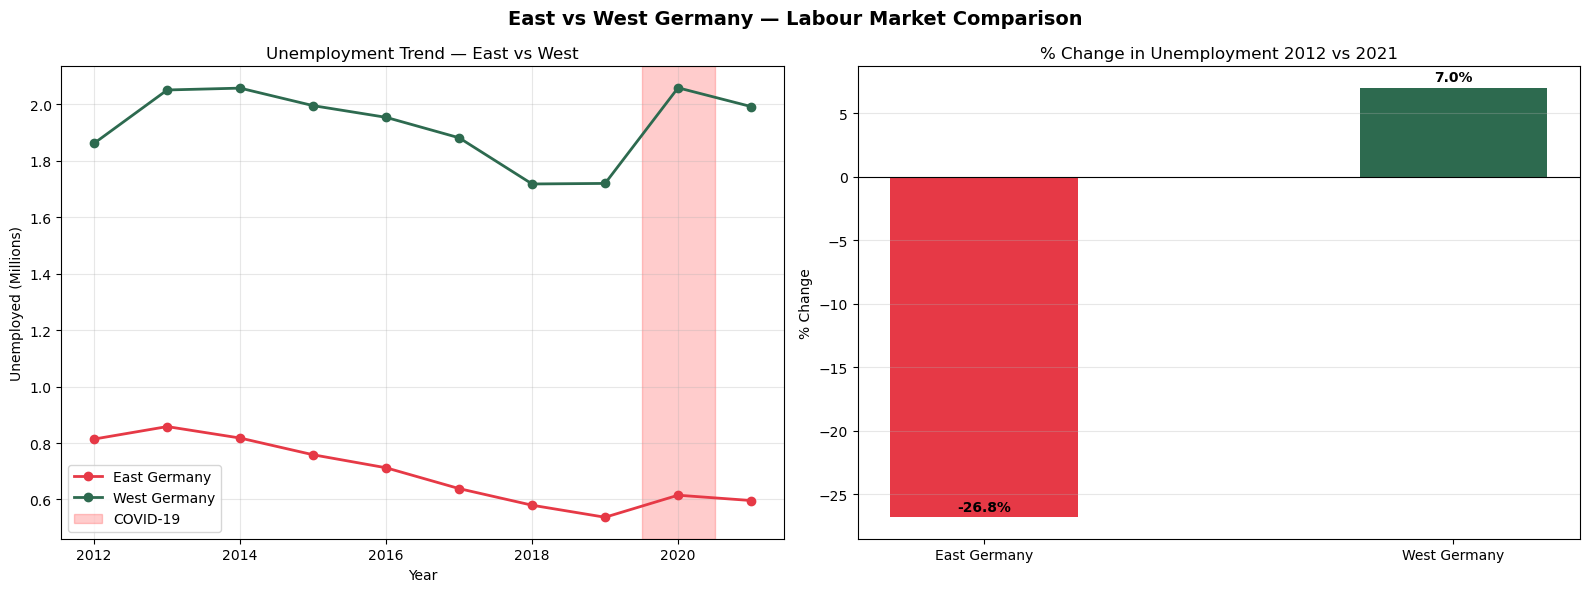

East Germany unemployment change 2012-2021: -26.8%
West Germany unemployment change 2012-2021: 7.0%


In [7]:
# Cell 6 — East vs West Germany
# East Germany states (former DDR)
east_states = ['Brandenburg', 'Mecklenburg-Vorpommern', 'Sachsen', 
               'Sachsen-Anhalt', 'Thüringen', 'Berlin']
west_states = ['Schleswig-Holstein', 'Hamburg', 'Niedersachsen', 'Bremen',
               'Nordrhein-Westfalen', 'Hessen', 'Rheinland-Pfalz',
               'Baden-Württemberg', 'Bayern', 'Saarland']

state_yearly['region'] = state_yearly['state'].apply(
    lambda x: 'East Germany' if x in east_states else 'West Germany'
)

# East vs West yearly comparison
east_west = state_yearly.groupby(['region', 'year'])['total_unemployed'].sum().reset_index()

# Pivot for comparison
east_west_pivot = east_west.pivot(index='year', columns='region', values='total_unemployed')
east_west_pivot = east_west_pivot / 1e6  # convert to millions

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('East vs West Germany — Labour Market Comparison', 
             fontsize=14, fontweight='bold')

# 1. Unemployment trend East vs West
east_west_pivot.plot(ax=axes[0], marker='o', linewidth=2,
                     color=['#e63946', '#2d6a4f'])
axes[0].axvspan(2019.5, 2020.5, alpha=0.2, color='red', label='COVID-19')
axes[0].set_title('Unemployment Trend — East vs West')
axes[0].set_ylabel('Unemployed (Millions)')
axes[0].set_xlabel('Year')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. % Change from 2012 to 2021
change = ((east_west_pivot.loc[2021] - east_west_pivot.loc[2012]) / 
           east_west_pivot.loc[2012] * 100).round(1)
bars = axes[1].bar(change.index, change.values, 
                   color=['#e63946', '#2d6a4f'], width=0.4)
axes[1].set_title('% Change in Unemployment 2012 vs 2021')
axes[1].set_ylabel('% Change')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, change.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, 
                 val + 0.5, f'{val}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("East Germany unemployment change 2012-2021:", 
      f"{change['East Germany']}%")
print("West Germany unemployment change 2012-2021:", 
      f"{change['West Germany']}%")

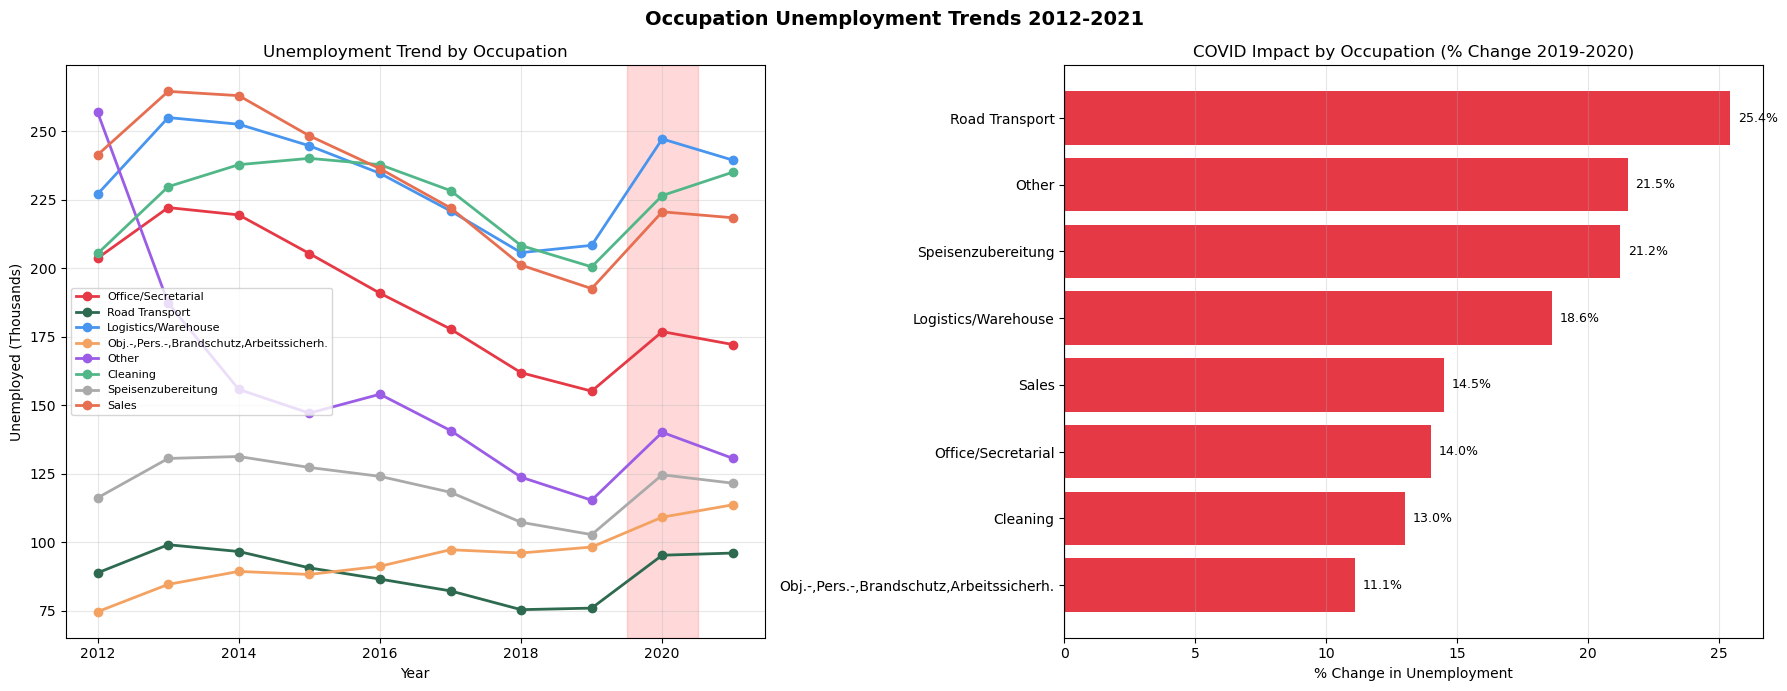

In [8]:
# Cell 7 — Occupation Trends Over Time
# Top 8 occupations
top8_occupations = top_occupations.head(8).index.tolist()

# Filter and aggregate
occ_trend = df_clean[df_clean['occupation_name'].isin(top8_occupations)]\
    .groupby(['occupation_name', 'year'])['total'].sum().reset_index()

# Shorten occupation names for readability
name_map = {
    'Lagerwirt.,Post,Zustellung,Güterumschlag': 'Logistics/Warehouse',
    'Verkauf (ohne Produktspezialisierung)': 'Sales',
    'Reinigung': 'Cleaning',
    'Büro und Sekretariat': 'Office/Secretarial',
    'Other/Unclassified': 'Other',
    'Fahrzeugführung im Straßenverkehr': 'Road Transport',
    'Sozialarbeit und Sozialpädagogik': 'Social Work',
    'Erziehung,Sozialarb.,Heilerziehungspfl.': 'Education/Care'
}
occ_trend['occupation_short'] = occ_trend['occupation_name'].map(name_map).fillna(occ_trend['occupation_name'])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Occupation Unemployment Trends 2012-2021', 
             fontsize=14, fontweight='bold')

# 1. Trend lines per occupation
colors = ['#e63946','#2d6a4f','#4895ef','#f4a261',
          '#9b5de5','#52b788','#aaaaaa','#e76f51']
for i, occ in enumerate(occ_trend['occupation_short'].unique()):
    data = occ_trend[occ_trend['occupation_short']==occ]
    axes[0].plot(data['year'], data['total']/1e3, 
                marker='o', label=occ, color=colors[i], linewidth=2)
axes[0].axvspan(2019.5, 2020.5, alpha=0.15, color='red')
axes[0].set_title('Unemployment Trend by Occupation')
axes[0].set_ylabel('Unemployed (Thousands)')
axes[0].set_xlabel('Year')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2. COVID impact by occupation (2019 vs 2020 change)
occ_2019 = occ_trend[occ_trend['year']==2019].set_index('occupation_short')['total']
occ_2020 = occ_trend[occ_trend['year']==2020].set_index('occupation_short')['total']
covid_impact = ((occ_2020 - occ_2019) / occ_2019 * 100).round(1).sort_values(ascending=True)

colors_impact = ['#e63946' if x > 0 else '#2d6a4f' for x in covid_impact.values]
axes[1].barh(covid_impact.index, covid_impact.values, color=colors_impact)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_title('COVID Impact by Occupation (% Change 2019-2020)')
axes[1].set_xlabel('% Change in Unemployment')
axes[1].grid(True, alpha=0.3, axis='x')
for i, (idx, val) in enumerate(covid_impact.items()):
    axes[1].text(val + 0.3 if val > 0 else val - 0.3, i, 
                f'{val}%', va='center', fontsize=9,
                ha='left' if val > 0 else 'right')

plt.tight_layout()
plt.show()